In [1]:
"""
Monthly climatology of sinking particle fluxes from the BATS Particle Interceptor
Trap System (PITS).

This module loads the PITS sediment-trap dataset (version v7) containing
elemental fluxes of carbon, nitrogen and phosphorus collected at the Bermuda
Atlantic Time-series Study (BATS) site from December 1988 to June 2025.
It computes the average flux for each calendar month at each trap depth and
returns the result as an ``xarray.Dataset``.  The dataset includes mass
fluxes and both raw and field-blank-corrected elemental fluxes measured at
nominal depths of 150, 200, 300 and 400 m【240416457143519†L96-L105】.

Variables
---------

The raw data file contains several flux measurements: three replicate
measurements (``M1``, ``M2``, ``M3``) and their average (``M_avg``) for total
mass flux, organic carbon flux (``C1``–``C3``, ``C_avg``), nitrogen flux
(``N1``–``N3``, ``N_avg``), phosphorus flux (``P1``–``P3``, ``P_avg``), and
field-blank-corrected carbon and nitrogen fluxes (``FBC1``–``FBC3``,
``FBC_avg``, ``FBN1``–``FBN3``, ``FBN_avg``).  Units are milligrams per
square metre per day for mass, carbon and nitrogen fluxes, and millimoles
per square metre per day for phosphorus fluxes.

Example
-------

::

    from bats_particle_flux_climatology import build_flux_climatology

    ds = build_flux_climatology('894099_v7_bats_particle_flux.csv')
    print(ds)
    ds.to_netcdf('bats_flux_monthly_climatology.nc')

"""

from __future__ import annotations

import io
from typing import Dict, Optional

import numpy as np
import pandas as pd
import requests
import xarray as xr

import os
wrkdir = "/g/data/vn19/pjb581/WOMBATmid-Optimization/data/observations"
os.chdir(wrkdir)
os.getcwd()


'/g/data/vn19/pjb581/WOMBATmid-Optimization/data/observations'

In [2]:
# Mapping of raw column names to concise variable names for the output dataset.
VARIABLES: Dict[str, str] = {
    'M1': 'mass_flux1',
    'M2': 'mass_flux2',
    'M3': 'mass_flux3',
    'M_avg': 'mass_flux_avg',
    'C1': 'organic_carbon_flux1',
    'C2': 'organic_carbon_flux2',
    'C3': 'organic_carbon_flux3',
    'C_avg': 'organic_carbon_flux_avg',
    'N1': 'nitrogen_flux1',
    'N2': 'nitrogen_flux2',
    'N3': 'nitrogen_flux3',
    'N_avg': 'nitrogen_flux_avg',
    'P1': 'phosphorus_flux1',
    'P2': 'phosphorus_flux2',
    'P3': 'phosphorus_flux3',
    'P_avg': 'phosphorus_flux_avg',
    'FBC1': 'fbc_carbon_flux1',
    'FBC2': 'fbc_carbon_flux2',
    'FBC3': 'fbc_carbon_flux3',
    'FBC_avg': 'fbc_carbon_flux_avg',
    'FBN1': 'fbc_nitrogen_flux1',
    'FBN2': 'fbc_nitrogen_flux2',
    'FBN3': 'fbc_nitrogen_flux3',
    'FBN_avg': 'fbc_nitrogen_flux_avg',
}

# Units for each variable.  Based on dataset metadata.
UNITS: Dict[str, str] = {
    'mass_flux1': 'mg_per_m2_per_day',
    'mass_flux2': 'mg_per_m2_per_day',
    'mass_flux3': 'mg_per_m2_per_day',
    'mass_flux_avg': 'mg_per_m2_per_day',
    'organic_carbon_flux1': 'mgC_per_m2_per_day',
    'organic_carbon_flux2': 'mgC_per_m2_per_day',
    'organic_carbon_flux3': 'mgC_per_m2_per_day',
    'organic_carbon_flux_avg': 'mgC_per_m2_per_day',
    'nitrogen_flux1': 'mgN_per_m2_per_day',
    'nitrogen_flux2': 'mgN_per_m2_per_day',
    'nitrogen_flux3': 'mgN_per_m2_per_day',
    'nitrogen_flux_avg': 'mgN_per_m2_per_day',
    'phosphorus_flux1': 'mmolP_per_m2_per_day',
    'phosphorus_flux2': 'mmolP_per_m2_per_day',
    'phosphorus_flux3': 'mmolP_per_m2_per_day',
    'phosphorus_flux_avg': 'mmolP_per_m2_per_day',
    'fbc_carbon_flux1': 'mgC_per_m2_per_day',
    'fbc_carbon_flux2': 'mgC_per_m2_per_day',
    'fbc_carbon_flux3': 'mgC_per_m2_per_day',
    'fbc_carbon_flux_avg': 'mgC_per_m2_per_day',
    'fbc_nitrogen_flux1': 'mgN_per_m2_per_day',
    'fbc_nitrogen_flux2': 'mgN_per_m2_per_day',
    'fbc_nitrogen_flux3': 'mgN_per_m2_per_day',
    'fbc_nitrogen_flux_avg': 'mgN_per_m2_per_day',
}


### DOWNLOAD

In [4]:
def load_flux_data(path_or_url: str) -> pd.DataFrame:
    """Load the particle flux CSV from a file path or remote URL.

    Parameters
    ----------
    path_or_url : str
        Local path or HTTP(S) URL to the particle flux CSV file.

    Returns
    -------
    pandas.DataFrame
        DataFrame containing all rows from the CSV.
    """
    if path_or_url.startswith(('http://', 'https://')):
        try:
            return pd.read_csv(path_or_url)
        except Exception:
            resp = requests.get(path_or_url)
            resp.raise_for_status()
            return pd.read_csv(io.BytesIO(resp.content))
    else:
        return pd.read_csv(path_or_url)

In [5]:
%%time

link = "https://datadocs.bco-dmo.org/dataset/894099/file/B1WAXZOhz6VKro/894099_v7_bats_particle_flux.csv"
ds = load_flux_data(link)
print(ds)


      Cruise_num Cruise_type                 Vessel        Date_deployed  \
0          10003   BATS Core      R/V Cape Henlopen  1988-12-16T23:47:00   
1          10004   BATS Core      R/V Cape Henlopen  1989-01-25T20:01:00   
2          10004   BATS Core      R/V Cape Henlopen  1989-01-25T20:01:00   
3          10004   BATS Core      R/V Cape Henlopen  1989-01-25T20:01:00   
4          10004   BATS Core      R/V Cape Henlopen  1989-01-25T20:01:00   
...          ...         ...                    ...                  ...   
1244       10427   BATS Core  R/V Atlantic Explorer  2025-05-03T18:07:00   
1245       10427   BATS Core  R/V Atlantic Explorer  2025-05-03T18:07:00   
1246       10428   BATS Core  R/V Atlantic Explorer  2025-06-02T21:47:00   
1247       10428   BATS Core  R/V Atlantic Explorer  2025-06-02T21:47:00   
1248       10428   BATS Core  R/V Atlantic Explorer  2025-06-02T21:47:00   

      Latitude_deployed  Longitude_deployed       Date_recovered  \
0                31

### PROCESS

In [6]:
def preprocess_flux(
    df: pd.DataFrame,
    depth_grid: Optional[np.ndarray] = None,
    depth_tolerance: float = 5.0,
    date_column: str = 'Date_deployed',
) -> pd.DataFrame:
    """Preprocess the raw flux DataFrame.

    Steps:
    * Parse the selected date column into a datetime and extract the
      calendar month (1–12).
    * Convert the ``Depth`` column to numeric and, if a depth grid is
      provided, snap depths to the nearest grid point within the given
      tolerance.  If no depth grid is provided, unique depths from the
      dataset are used directly without snapping.
    * Convert each flux variable to numeric and rename it according to
      ``VARIABLES``.
    * Drop rows where all selected variables are NaN.

    Parameters
    ----------
    df : pandas.DataFrame
        Raw particle flux dataset.
    depth_grid : numpy.ndarray, optional
        Array of depth levels to which depths are snapped.  If omitted,
        no snapping is performed and unique depths are used directly.
    depth_tolerance : float, optional
        Maximum allowed deviation between a sample depth and the
        nearest grid level to include the sample (used only when
        ``depth_grid`` is provided).
    date_column : str, optional
        Name of the date column to use for assigning months.  Must be
        ``Date_deployed`` or ``Date_recovered``.  Default is
        ``Date_deployed``.

    Returns
    -------
    pandas.DataFrame
        A tidy DataFrame with columns ``month``, ``depth`` and one
        column per flux variable.
    """
    if df.empty:
        return df
    df = df.copy()
    # Parse datetime
    if date_column not in df.columns:
        raise ValueError(f"Date column '{date_column}' not found in data")
    df['datetime'] = pd.to_datetime(df[date_column], errors='coerce')
    df.dropna(subset=['datetime'], inplace=True)
    df['month'] = df['datetime'].dt.month.astype(int)
    # Depth handling
    if 'Depth' not in df.columns:
        raise ValueError("Missing 'Depth' column in particle flux data")
    df['depth_orig'] = pd.to_numeric(df['Depth'], errors='coerce')
    df.dropna(subset=['depth_orig'], inplace=True)
    if depth_grid is not None:
        # Snap to nearest grid level
        idxs = np.abs(df['depth_orig'].values[:, None] - depth_grid[None, :]).argmin(axis=1)
        snapped = depth_grid[idxs]
        within = np.abs(df['depth_orig'] - snapped) <= depth_tolerance
        df = df.loc[within].copy()
        df['depth'] = snapped[within.values]
    else:
        # Use original depths directly
        df['depth'] = df['depth_orig']
    # Convert variables to numeric and rename
    present_vars = []
    for raw_name, out_name in VARIABLES.items():
        if raw_name not in df.columns:
            continue
        series = pd.to_numeric(df[raw_name], errors='coerce')
        if series.notna().any():
            df[out_name] = series
            present_vars.append(out_name)
    if not present_vars:
        # No variables found
        return pd.DataFrame()
    # Drop rows with all NaN across selected variables
    df.dropna(subset=present_vars, how='all', inplace=True)
    return df[['month', 'depth'] + present_vars]


### CLIMATOLOGY

In [7]:
def compute_monthly_climatology(df: pd.DataFrame) -> pd.DataFrame:
    """Group by month and depth and compute the mean of each variable."""
    if df.empty:
        return df
    grouped = df.groupby(['month', 'depth'], as_index=True)
    clim = grouped.mean(numeric_only=True)
    clim.sort_index(inplace=True)
    return clim


### BUILD

In [8]:
def build_flux_climatology(
    path_or_url: str,
    depth_grid: Optional[np.ndarray] = None,
    depth_tolerance: float = 5.0,
    date_column: str = 'Date_deployed',
) -> xr.Dataset:
    """Compute monthly climatology from the BATS particle flux dataset.

    Parameters
    ----------
    path_or_url : str
        Local path or URL to the particle flux CSV.
    depth_grid : numpy.ndarray, optional
        Array of depth levels for snapping.  If omitted, unique depths
        from the data are used.  To align with other climatologies,
        supply a custom grid (e.g., np.arange(0, 500, 10)).
    depth_tolerance : float, optional
        Tolerance for depth snapping when a grid is provided.
    date_column : str, optional
        Column name to use for assigning month (either
        ``Date_deployed`` or ``Date_recovered``).

    Returns
    -------
    xarray.Dataset
        Dataset with dimensions ``depth`` and ``month`` containing
        monthly mean fluxes.
    """
    raw_df = load_flux_data(path_or_url)
    tidy = preprocess_flux(raw_df, depth_grid=depth_grid, depth_tolerance=depth_tolerance, date_column=date_column)
    if tidy.empty:
        return xr.Dataset()
    clim_df = compute_monthly_climatology(tidy)
    # Determine depth and month axes
    months = np.arange(1, 13)
    if depth_grid is not None:
        depths = depth_grid
    else:
        depths = np.sort(tidy['depth'].unique())
    ds = xr.Dataset()
    # unstack multi-index to DataFrame with index=depths, columns=months for each var
    unstacked = clim_df.unstack(level=0)
    for var in unstacked.columns.get_level_values(0).unique():
        var_df = unstacked[var]
        # reindex to full axis
        var_df = var_df.reindex(index=depths, columns=months, fill_value=np.nan)
        data = var_df.values.astype(float)
        ds[var] = xr.DataArray(
            data,
            coords={'depth': depths, 'month': months},
            dims=['depth', 'month'],
            name=var,
            attrs={'units': UNITS.get(var)}
        )
    ds['depth'].attrs['units'] = 'meters'
    ds['month'].attrs['long_name'] = 'Calendar month'
    return ds


### call

In [9]:
%%time

link = "https://datadocs.bco-dmo.org/dataset/894099/file/B1WAXZOhz6VKro/894099_v7_bats_particle_flux.csv"
ds = build_flux_climatology(link)
print(ds)


<xarray.Dataset> Size: 9kB
Dimensions:                  (depth: 4, month: 12)
Coordinates:
  * depth                    (depth) int64 32B 150 200 300 400
  * month                    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables: (12/24)
    mass_flux1               (depth, month) float64 384B 198.5 249.0 ... nan
    mass_flux2               (depth, month) float64 384B 180.6 260.8 ... nan
    mass_flux3               (depth, month) float64 384B 241.6 265.7 ... nan nan
    mass_flux_avg            (depth, month) float64 384B 203.2 259.0 ... nan
    organic_carbon_flux1     (depth, month) float64 384B 31.21 45.11 ... nan nan
    organic_carbon_flux2     (depth, month) float64 384B 31.25 51.21 ... nan
    ...                       ...
    fbc_carbon_flux3         (depth, month) float64 384B 45.8 50.31 ... nan nan
    fbc_carbon_flux_avg      (depth, month) float64 384B 39.17 54.17 ... nan nan
    fbc_nitrogen_flux1       (depth, month) float64 384B 4.619 7.172 ... nan nan
  

In [10]:
ds.data_vars

Data variables:
    mass_flux1               (depth, month) float64 384B 198.5 249.0 ... nan
    mass_flux2               (depth, month) float64 384B 180.6 260.8 ... nan
    mass_flux3               (depth, month) float64 384B 241.6 265.7 ... nan nan
    mass_flux_avg            (depth, month) float64 384B 203.2 259.0 ... nan
    organic_carbon_flux1     (depth, month) float64 384B 31.21 45.11 ... nan nan
    organic_carbon_flux2     (depth, month) float64 384B 31.25 51.21 ... nan
    organic_carbon_flux3     (depth, month) float64 384B 37.52 47.28 ... nan nan
    organic_carbon_flux_avg  (depth, month) float64 384B 32.73 48.25 ... nan
    nitrogen_flux1           (depth, month) float64 384B 4.655 7.466 ... nan
    nitrogen_flux2           (depth, month) float64 384B 4.901 8.585 ... nan
    nitrogen_flux3           (depth, month) float64 384B 5.499 7.62 ... nan nan
    nitrogen_flux_avg        (depth, month) float64 384B 5.012 8.016 ... nan
    phosphorus_flux1         (depth, month) f

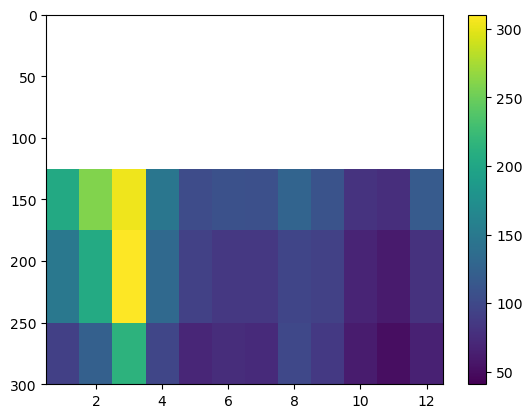

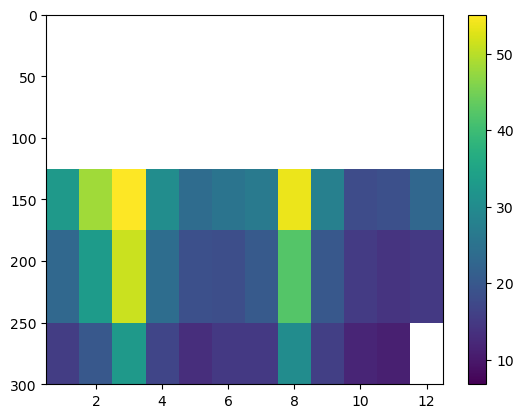

In [14]:
import matplotlib.pyplot as plt

plt.figure()
plt.pcolormesh(ds.coords['month'], ds.coords['depth'], ds['mass_flux_avg'])
plt.ylim(300,0)
plt.colorbar()

plt.figure()
plt.pcolormesh(ds.coords['month'], ds.coords['depth'], ds['organic_carbon_flux_avg'])
plt.ylim(300,0)
plt.colorbar()



### SAVE

In [15]:
%%time
    
ds.to_netcdf('./bats_particleflux_monthly_climatology.nc')

CPU times: user 252 ms, sys: 108 ms, total: 359 ms
Wall time: 707 ms
